Desenvolvimento de IA para Análise Preditiva [T3] - M1S13 - Projeto Final Módulo 1 - 06/10/2026

Aluna: Isabela Gomes da Costa

DESAFIO:

Atuar como Cientista de Dados para estruturar um Pipeline Preditivo completo aplicado à Indústria 4.0.

O Problema: Um parque fabril monitorado por sensores necessita prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção. A variável alvo do projeto é binária: Falha = 1 (quando há uma avaria detectada) e Falha = 0 (funcionamento normal).

Link da Base de Dados (.csv): https://drive.google.com/drive/folders/1_QcYvhSoJO6SxOJz8Om6gaVuWyPZKdMs?usp=sharing

Além da base de dados, o engenheiro responsável disponibilizou alguns detalhes importantes que você precisa levar em consideração: anotações do Departamento de Engenharia.


Fase 0: Ambiente e importações

In [4]:
# Instalando SMOTE
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Importação de Bibliotecas de terceiros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from imblearn.over_sampling import SMOTE

pd.set_option("display.width", 120)
sns.set_style("whitegrid")

print("Ambiente pronto!")

Ambiente pronto!


Fase 1: Análise Exploratória (EDA)

In [6]:
# Carregando o dataset
url_dados = (
    "https://drive.google.com/uc?export=download"
    "&id=1er0sPjY51RymKrRkzZkjFOVwJ8PEZoAZ"
)

df = pd.read_csv(url_dados)

display(df.head())
print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas")

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


Dimensões: 10000 linhas e 14 colunas


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

Verificando os tipos dos dados, temos que todas as colunas estão de acordo com o que é especificado no documento "Anotações do Departamento de Engenharia". Além disso, podemos verificar que há 500 valores nulos nas colunas temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm.

In [8]:
display(df.describe())

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Analisando os valores estatísticos (percepções iniciais), temos:

temperatura_ar_k e temperatura_processo_k: variáveis com comportamento similar, além de possírem a mesma escala, variação pequena entre os valores máximos e mínimos, além de desvios padrão baixos. 

velocidade_rotacao_rpm: nessa coluna algo me chamou bastante atenção, seu desvio padrão, e olhando a distribuição dos quartis, já tenho um indicativo de um possível outlier, pois, até 75% dos dados, os valores aumentam de uma maneira quase constante, mas no último quartil, há um grande salto no valor, este que difere muito da média.

torque_nm e desgaste_ferramenta_min: aqui tem-se um comportamento similar ao anterior, valores máximos longe das médias, desvios padrão relativamente altos.

dados de falha: estes valores são binárias, codificadas como 0 e 1, então a interpretação estatística pelo describe não é muito informativa, visualizarei eles melhor através dos gráficos a seguir. No entanto, vale pontuar que as variáveis possuem médias bem baixas, e apenas o valor máximo preechido pelo valor 1, ou seja, vemos que a maior parte das linhas são referentes a equipamentos sem falha, ou seja, isso já implica um desbalanceamento na base de dados que deverá ser tratado posteriormente.


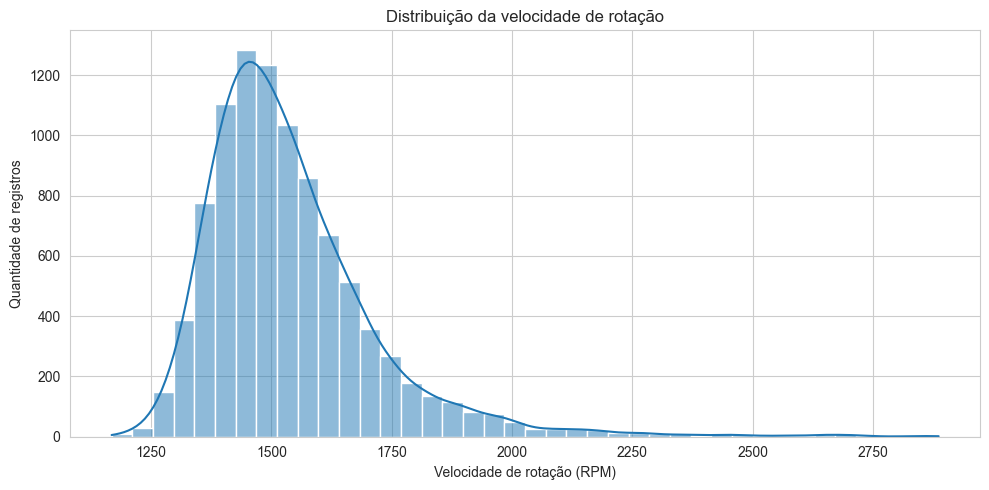

In [9]:
# Gráficos iniciais

# Gráfico de histograma para confirmar se minha percepção sobre a velocidade de rotação está correta

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="velocidade_rotacao_rpm",
    bins=40,
    kde=True
)

plt.title("Distribuição da velocidade de rotação")
plt.xlabel("Velocidade de rotação (RPM)")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O gráfico confirma a distribuição assimétrica que percebi anteriormente, onde a maior concentração está aproximadamente entre 1.400 e 1.600 RPM (cauda alongada à direita), com poucas observações chegando perto de 2.900 RPM.

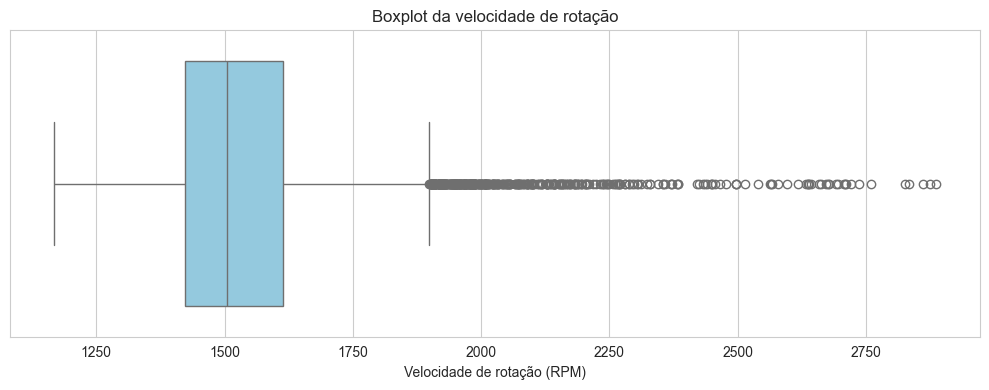

In [10]:
# Gráfico de boxplot para verificar a presença de outliers na variável velocidade de rotação

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="velocidade_rotacao_rpm",
    color="skyblue"
)

plt.title("Boxplot da velocidade de rotação")
plt.xlabel("Velocidade de rotação (RPM)")
plt.tight_layout()
plt.show()

O boxplox demonstra mais claramente os valores extremos acima de 1.898 RPM, reforçando a assimetria à direita observada no histograma. Como, mesmo sendo outliers, são diversos valores, isso corrobora para a interpretação de que são inerentes aos processos dos equipamentos, e não dados errôneos, ou, se fossem poucos registros nessa situação, algo pontual, então eles  serão mantidos por enquanto.

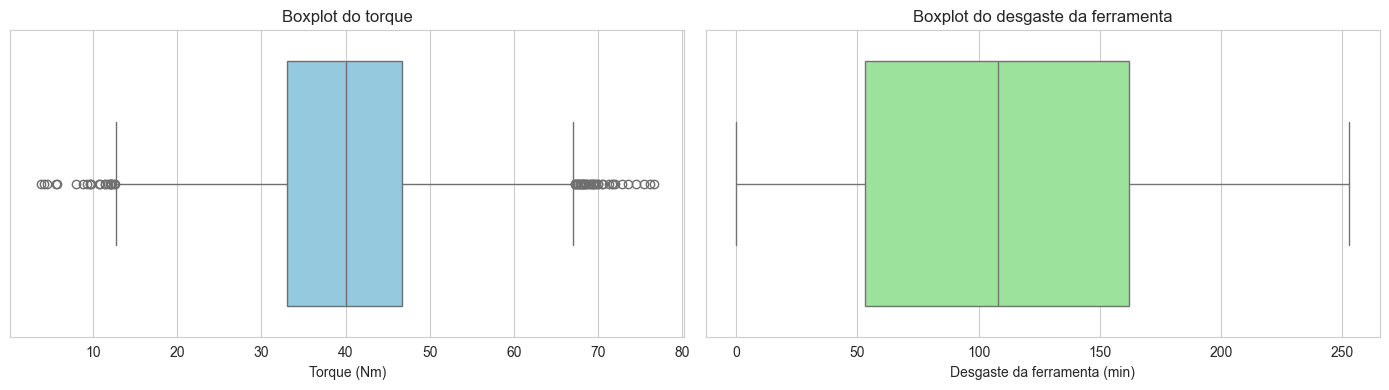

In [11]:
# Gráfico de boxplot para verificar a presença de outliers nas variáveis torque e desgaste de ferramenta

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=df,
    x="torque_nm",
    color="skyblue",
    ax=axes[0]
)
axes[0].set_title("Boxplot do torque")
axes[0].set_xlabel("Torque (Nm)")

sns.boxplot(
    data=df,
    x="desgaste_ferramenta_min",
    color="lightgreen",
    ax=axes[1]
)
axes[1].set_title("Boxplot do desgaste da ferramenta")
axes[1].set_xlabel("Desgaste da ferramenta (min)")

plt.tight_layout()
plt.show()

Anteriormente identifiquei estes dados como similares, mas olhando melhor através do boxplot de cada um, vemos que o comportamento não é parecido. O torque apresenta valores extremos tanto abaixo quanto acima da faixa delimitada do boxplot. Já o desgaste da ferramenta, não apresenta outliers por esse método. Isso mostra que máximos distantes da média não são suficientes para determinar um outlier.



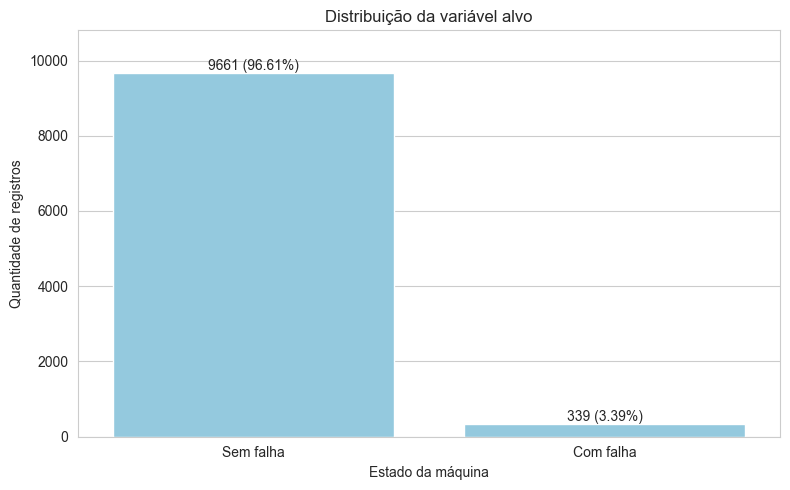

In [12]:
# Gráfico de distribuição da variável falha_maquina

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="falha_maquina",
    order=[0, 1],
    color="skyblue"
)

for barra in ax.patches:
    quantidade = int(barra.get_height())
    percentual = quantidade / len(df) * 100

    ax.annotate(
        f"{quantidade} ({percentual:.2f}%)",
        (barra.get_x() + barra.get_width() / 2, quantidade),
        ha="center",
        va="bottom"
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Sem falha", "Com falha"])
ax.set_ylim(0, len(df) * 1.08)

plt.title("Distribuição da variável alvo")
plt.xlabel("Estado da máquina")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O gráfico já informa de maneira explícita, 96,61% das medições não apresentam falha.

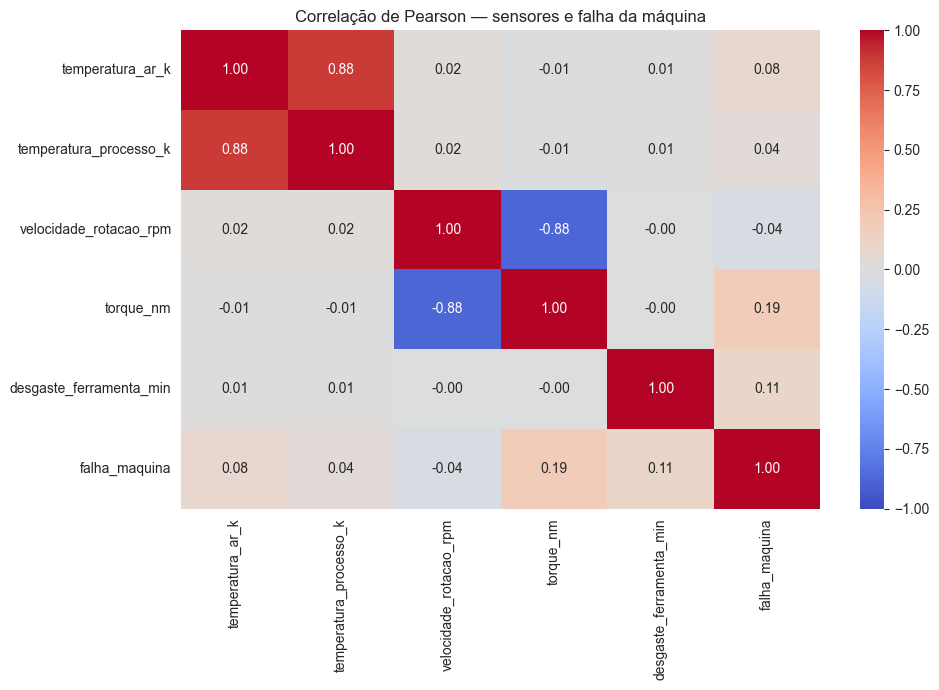

In [13]:
# Gráfico de correlação

colunas_correlacao = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "falha_maquina"
]

correlacao = df[colunas_correlacao].corr(method="pearson")

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlação de Pearson — sensores e falha da máquina")
plt.tight_layout()
plt.show()

Aqui a uma confirmação de algo que comentei inicialmente, as variáveis de temperatura possuem forte correlação positiva. Além disso, vale citar, que torque e velocidade apresentam forte correlação negativa. Essas associações não comprovam proporcionalidade ou causalidade.

Em relação à falha da máquina, variável alvo, torque (0,19) e desgaste da ferramenta (0,11) apresentam as maiores correlações positivas, embora sejam bem baixas. Porém, não descarto sua utilidade na modelagem, pois as falhas podem depender de relações não lineares.

Concluindo a primeira etapa do projeto, já há alguns direcionais para as próximas etapas. Terei que tratar/verificar os dados nulos, verificar a existência de dados duplicados, investigar as variáveis com valores extremos vistas nos boxplots, além de considerar o desbalanceamento do target no treino.

Fase 2: Limpeza e Tratamento de Dados (Data Prep)

In [14]:
# Verificação de linhas duplicadas

quantidade_duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas: {quantidade_duplicadas}")

df_limpo = df.drop_duplicates().copy()

print(f"Linhas antes: {len(df)}")
print(f"Linhas depois: {len(df_limpo)}")

Linhas duplicadas: 0
Linhas antes: 10000
Linhas depois: 10000


O banco de dados não possuia nenhuma linha duplicada, então seguimos com 10000 linhas.

In [15]:
# Verificação de valores nulos

resumo_nulos = pd.DataFrame({
    "quantidade": df_limpo.isna().sum(),
    "percentual": df_limpo.isna().mean() * 100
})

display(resumo_nulos)

,quantidade,percentual
udi,0,0.0
id_produto,0,0.0
tipo,0,0.0
temperatura_ar_k,500,5.0
temperatura_processo_k,500,5.0
velocidade_rotacao_rpm,500,5.0
torque_nm,500,5.0
desgaste_ferramenta_min,0,0.0
falha_maquina,0,0.0
falha_twf,0,0.0


Conforme comentei anteriormente, as variáveis de temperatura, velocidade e torque possuem 500 linhas com valores nulos.

In [16]:
# Verificação se os valores nulos estão nas mesmas linhas

colunas_com_nulos = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]

mascara_nulos = df[colunas_com_nulos].isna()

# Linhas com pelo menos uma dessas variáveis ausente
linhas_com_nulos = df.loc[mascara_nulos.any(axis=1)]

display(linhas_com_nulos)

print(
    "Linhas com pelo menos um nulo:",
    mascara_nulos.any(axis=1).sum()
)
print(
    "Linhas com as quatro variáveis nulas:",
    mascara_nulos.all(axis=1).sum()
)

mesmas_linhas = mascara_nulos.eq(
    mascara_nulos.iloc[:, 0],
    axis=0
).all().all()

print("Os nulos estão nas mesmas linhas nas quatro colunas?", mesmas_linhas)


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9783,9784,H39197,H,NaN,NaN,NaN,NaN,66,0,0,0,0,0,0
9896,9897,M24756,M,NaN,NaN,NaN,NaN,173,0,0,0,0,0,0
9909,9910,L57089,L,NaN,NaN,NaN,NaN,2,0,0,0,0,0,0
9920,9921,H39334,H,NaN,NaN,NaN,NaN,28,0,0,0,0,0,0


Linhas com pelo menos um nulo: 500
Linhas com as quatro variáveis nulas: 500
Os nulos estão nas mesmas linhas nas quatro colunas? True


In [17]:
# Criando uma nova base a partir dos dados sem duplicatas
df_sem_nulos = df_limpo.copy()

# Removendo linhas com valores ausentes nas quatro variáveis
df_sem_nulos = df_sem_nulos.dropna(subset=colunas_com_nulos)

print(f"Linhas antes: {len(df_limpo)}")
print(f"Linhas depois: {len(df_sem_nulos)}")
print(f"Linhas removidas: {len(df_limpo) - len(df_sem_nulos)}")

display(df_sem_nulos.isna().sum())

Linhas antes: 10000
Linhas depois: 9500
Linhas removidas: 500


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

Na etapa anterior, criei o dataframe df_limpo após verificar as linhas duplicadas, para manter a base original em df sem modificações (mesmo que não tenha sido encontrado nenhuma linha duplicada). A partir dele, criei df_sem_nulos para remover os registros com valores ausentes, mantendo também a versão anterior para comparação. Verificando os valores nulos, identifiquei que as quatro variáveis apresentam dados ausentes nas mesmas 500 linhas. Como esses registros não possuem informações de temperatura do ar, temperatura do processo, velocidade de rotação e torque, optei por removê-los em vez de preencher quatro medições com média ou mediana. Essa decisão preserva os valores observados dos sensores, mas reduz a base e pode alterar sua representatividade. A nova base foi criada como df_sem_nulos, mantendo df_limpo para comparação.

In [18]:
# Verificação se a proporção de falhas foi muito alterada pela limpeza dos dados

comparacao = pd.DataFrame({
    "antes (%)": df_limpo["falha_maquina"].value_counts(normalize=True) * 100,
    "depois (%)": df_sem_nulos["falha_maquina"].value_counts(normalize=True) * 100
})

display(comparacao)

,antes (%),depois (%)
falha_maquina,,
0,96.61,96.610526
1,3.39,3.389474


Não houve modificação na proporção de dados de quipamentos com falha.

OBS.: Irei gerar o df com os nulos preenchidos pela mediana, pra utilizar nos passos seguintes e ter essa compração, e no fim, definir qual linha desempenhou melhor.

In [19]:
# Criando uma cópia da base df_limpo para preenchimento dos valores ausentes com a mediana

df_mediana = df_limpo.copy()

colunas_com_nulos = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]

# Calculando as medianas e preenchendo os valores ausentes
medianas = df_mediana[colunas_com_nulos].median()

df_mediana[colunas_com_nulos] = (
    df_mediana[colunas_com_nulos].fillna(medianas)
)

print("Medianas utilizadas:")
display(medianas)

print("Valores nulos após o preenchimento:")
display(df_mediana[colunas_com_nulos].isna().sum())

print(f"Dimensões: {df_mediana.shape[0]} linhas e {df_mediana.shape[1]} colunas")

Medianas utilizadas:


temperatura_ar_k           300.1
temperatura_processo_k     310.1
velocidade_rotacao_rpm    1504.0
torque_nm                   40.1
dtype: float64

Valores nulos após o preenchimento:


temperatura_ar_k          0
temperatura_processo_k    0
velocidade_rotacao_rpm    0
torque_nm                 0
dtype: int64

Dimensões: 10000 linhas e 14 colunas


A partir de df_limpo, criei uma cópia chamada df_mediana e preenchi os valores ausentes das quatro variáveis com suas respectivas medianas. Escolhi essa medida por ser menos sensível aos valores extremos, especialmente os observados na velocidade de rotação e no torque. Dessa forma, os registros são preservados, mantendo a base anterior para comparação.

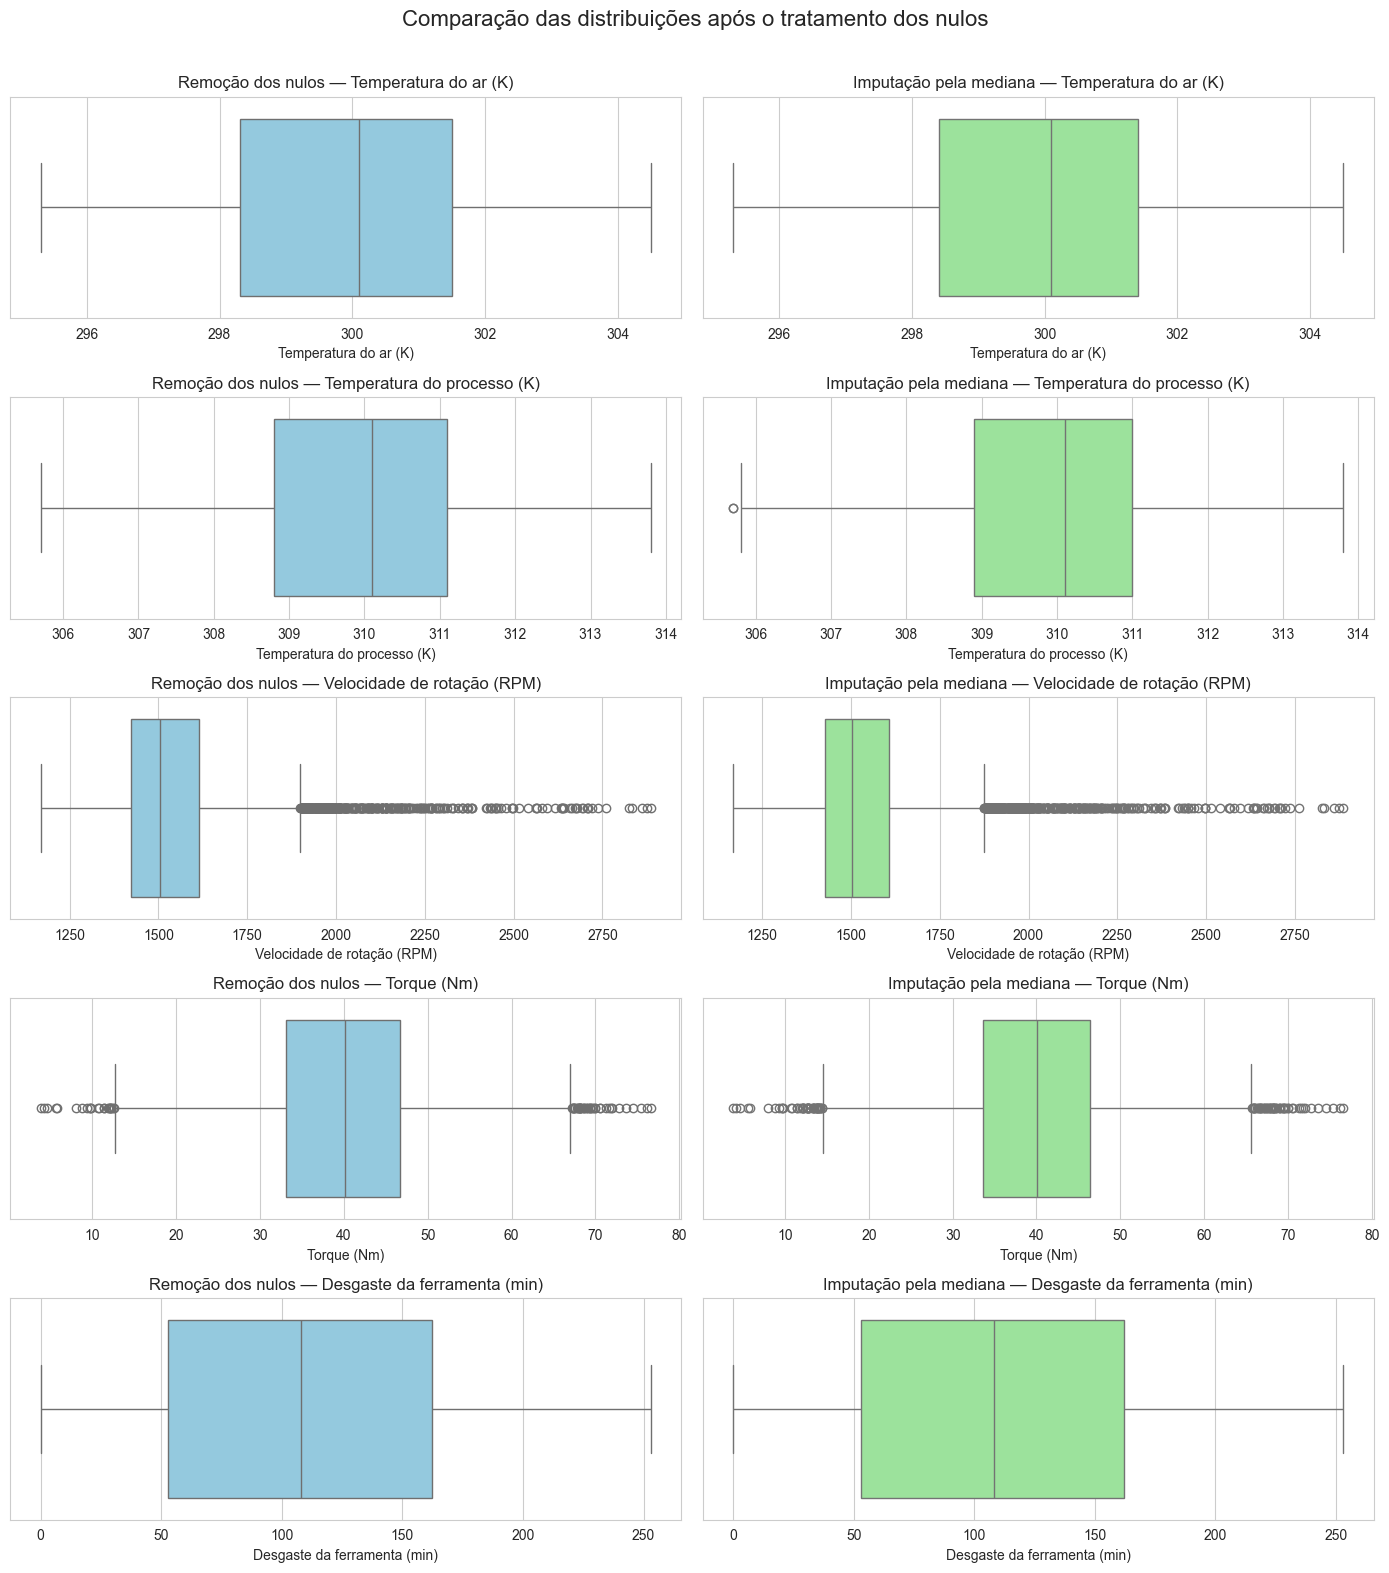

In [20]:
# Gráfico de boxplot das variáveis explicativas para verificar a presença de outliers após o tratamento dos valores ausentes

variaveis_boxplot = {
    "temperatura_ar_k": "Temperatura do ar (K)",
    "temperatura_processo_k": "Temperatura do processo (K)",
    "velocidade_rotacao_rpm": "Velocidade de rotação (RPM)",
    "torque_nm": "Torque (Nm)",
    "desgaste_ferramenta_min": "Desgaste da ferramenta (min)"
}

fig, axes = plt.subplots(
    nrows=len(variaveis_boxplot),
    ncols=2,
    figsize=(14, 16),
    sharex="row"
)

for linha, (coluna, rotulo) in enumerate(variaveis_boxplot.items()):
    sns.boxplot(
        data=df_sem_nulos,
        x=coluna,
        color="skyblue",
        ax=axes[linha, 0]
    )
    axes[linha, 0].set_title(f"Remoção dos nulos — {rotulo}")
    axes[linha, 0].set_xlabel(rotulo)

    sns.boxplot(
        data=df_mediana,
        x=coluna,
        color="lightgreen",
        ax=axes[linha, 1]
    )
    axes[linha, 1].set_title(f"Imputação pela mediana — {rotulo}")
    axes[linha, 1].set_xlabel(rotulo)

fig.suptitle(
    "Comparação das distribuições após o tratamento dos nulos",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Comparando os boxplots, observei poucas diferenças visuais entre os tratamentos. As medianas permaneceram semelhantes, enquanto algumas caixas ficaram ligeiramente mais estreitas após o preenchimento pela mediana. Os valores extremos de rotação e torque continuam presentes. Na temperatura do processo, a alteração dos quartis fez um valor baixo passar a ser identificado como candidato a outlier. Essas semelhanças nas distribuições não garantem o mesmo desempenho dos modelos, que será comparado nas próximas etapas. Além do valor outlier citado pra variável temperatura do processo, quando considerada a base com os nulos preenchidos pela mediana, em ambas as bases, a velocidade de rotação apresenta candidatos a outliers acima da haste superior, enquanto o torque apresenta candidatos abaixo da haste inferior e acima da superior.

Fase 3: Feature Engineering

In [21]:
# Criando a variável potencia: velocidade de rotação × torque

df_sem_nulos["potencia"] = (
    df_sem_nulos["velocidade_rotacao_rpm"]
    * df_sem_nulos["torque_nm"]
)

df_mediana["potencia"] = (
    df_mediana["velocidade_rotacao_rpm"]
    * df_mediana["torque_nm"]
)

# Visualizando os resultados

colunas_potencia = ["velocidade_rotacao_rpm", "torque_nm", "potencia"]

print("Base com remoção dos nulos:")
display(df_sem_nulos[colunas_potencia].head())

print("Base com imputação pela mediana:")
display(df_mediana[colunas_potencia].head())

Base com remoção dos nulos:


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
4,1408.0,40.0,56320.0
5,1425.0,41.9,59707.5


Base com imputação pela mediana:


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


Após o tratamento dos valores ausentes, criei a variável potencia nas duas bases, multiplicando a velocidade de rotação pelo torque, conforme sugerido no enunciado. Essa variável combina duas características de operação e representa uma medida proporcional à potência mecânica. O resultado está em RPM × Nm, e não em watts.

In [22]:
# Criando outra variável: diferença de temperatura nas duas bases

df_sem_nulos["diferenca_temperatura_k"] = (
    df_sem_nulos["temperatura_processo_k"]
    - df_sem_nulos["temperatura_ar_k"]
)

df_mediana["diferenca_temperatura_k"] = (
    df_mediana["temperatura_processo_k"]
    - df_mediana["temperatura_ar_k"]
)

# Visualizando os resultados da diferença de temperatura

colunas_temperatura = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "diferenca_temperatura_k"
]

print("Base com remoção dos nulos:")
display(df_sem_nulos[colunas_temperatura].head())

print("Base com imputação pela mediana:")
display(df_mediana[colunas_temperatura].head())

Base com remoção dos nulos:


,temperatura_ar_k,temperatura_processo_k,diferenca_temperatura_k
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
4,298.2,308.7,10.5
5,298.1,308.6,10.5


Base com imputação pela mediana:


,temperatura_ar_k,temperatura_processo_k,diferenca_temperatura_k
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,300.1,310.1,10.0
4,298.2,308.7,10.5


Além da variável potencia, criei diferenca_temperatura_k, subtraindo a temperatura do ar da temperatura do processo. Essa combinação representa a diferença térmica entre o processo e o ambiente e pode contribuir para identificar condições associadas às falhas. Sua contribuição será avaliada na modelagem.

In [24]:
print("Base com remoção dos nulos:")
df_sem_nulos.info()

print("\nBase com imputação pela mediana:")
df_mediana.info()

Base com remoção dos nulos:
<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      9500 non-null   int64  
 1   id_produto               9500 non-null   str    
 2   tipo                     9500 non-null   str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  9500 non-null   int64  
 8   falha_maquina            9500 non-null   int64  
 9   falha_twf                9500 non-null   int64  
 10  falha_hdf                9500 non-null   int64  
 11  falha_pwf                9500 non-null   int64  
 12  falha_osf                9500 non-null   int64  
 13  falha_rnf                9500 non-null   int64  
 14  potencia    

In [25]:
colunas_comparacao = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "potencia",
    "diferenca_temperatura_k"
]

comparacao_estatistica = pd.concat(
    {
        "Sem nulos": df_sem_nulos[colunas_comparacao].describe(),
        "Mediana": df_mediana[colunas_comparacao].describe()
    },
    axis=1
)

# Colocando os dois tratamentos lado a lado para cada variável
comparacao_estatistica = comparacao_estatistica.swaplevel(
    0, 1, axis=1
).reindex(colunas_comparacao, axis=1, level=0)

display(comparacao_estatistica.round(2))

temperatura_ar_k           temperatura_processo_k           velocidade_rotacao_rpm           torque_nm  \
             Sem nulos   Mediana              Sem nulos   Mediana              Sem nulos   Mediana Sem nulos   
count           9500.0  10000.00                9500.00  10000.00                9500.00  10000.00   9500.00   
mean             300.0    300.01                 310.00    310.01                1539.25   1537.48     39.97   
std                2.0      1.95                   1.49      1.45                 180.27    175.88     10.00   
min              295.3    295.30                 305.70    305.70                1168.00   1168.00      3.80   
25%              298.3    298.40                 308.80    308.90                1423.00   1427.00     33.10   
50%              300.1    300.10                 310.10    310.10                1504.00   1504.00     40.10   
75%              301.5    301.40                 311.10    311.00                1613.00   1606.00     46.70   
max              304.5    304.50                 313.80    313.80                2886.00   2886.00     76.60   

                desgaste_ferramenta_min            potencia           diferenca_temperatura_k            
        Mediana               Sem nulos   Mediana Sem nulos   Mediana               Sem nulos   Mediana  
count  10000.00                 9500.00  10000.00   9500.00  10000.00                  9500.0  10000.00  
mean      39.98                  108.09    107.95  59952.79  59970.67                    10.0     10.00  
std        9.74                   63.58     63.65  10209.58   9951.34                     1.0      0.97  
min        3.80                    0.00      0.00  10966.80  10966.80                     7.6      7.60  
25%       33.60                   53.00     53.00  53067.68  53497.05                     9.3      9.30  
50%       40.10                  108.00    108.00  59865.60  60310.40                     9.8      9.90  
75%       46.40                  162.25    162.00  66873.75  66412.98                    11.0     10.90  
max       76.60                  253.00    253.00  99980.40  99980.40                    12.1     12.10

Conferindo o .info(), as duas bases passaram a ter 16 colunas, com o tipo dos dados das colunas novas de acordo com as variáveis que representam.
Comparando o .describe(), observei pequenas diferenças nas médias e uma redução dos desvios padrão das quatro variáveis preenchidas. O que é esperado, pois a imputação adicionou valores centrais, diminuindo a dispersão.
Na variável potencia, a média passou de 59952,79 para 59970,67, enquanto a mediana passou de 59865,60 para 60310,40. Os 500 registros preenchidos receberam o mesmo produto de rotação e torque, o que aumentou a concentração nesse valor. Na diferença de temperatura, a média permaneceu próxima de 10 K nas duas bases, com pequenas alterações na mediana e na dispersão.
Os mínimos e máximos das novas variáveis permaneceram iguais. Embora os resumos sejam semelhantes, ainda será necessário comparar o desempenho dos modelos para avaliar o efeito de cada tratamento.